In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = (
    "expandable_segments:True,garbage_collection_threshold:0.6"
)

In [2]:
import torch
from accelerate import Accelerator
from transformers import Sam3VideoConfig, Sam3VideoModel, Sam3VideoProcessor
from transformers.video_utils import load_video

CUSTOM_RESOLUTION = 560
FRAMES_TO_TRACK = 250

In [3]:
# Load model and processor
device = Accelerator().device
print(f"Using device: {device}")

print(
    f"Loading model and processor (custom resolution: {CUSTOM_RESOLUTION}x{CUSTOM_RESOLUTION})..."
)
config = Sam3VideoConfig.from_pretrained("facebook/sam3")
config.image_size = CUSTOM_RESOLUTION
model = Sam3VideoModel.from_pretrained("facebook/sam3", config=config).to(
    device, dtype=torch.bfloat16
)
processor = Sam3VideoProcessor.from_pretrained(
    "facebook/sam3", size={"height": CUSTOM_RESOLUTION, "width": CUSTOM_RESOLUTION}
)

Using device: cuda
Loading model and processor (custom resolution: 560x560)...


Loading weights: 100%|██████████| 1797/1797 [00:02<00:00, 862.24it/s, Materializing param=tracker_neck.fpn_layers.3.proj2.weight]                                                  


In [4]:
# Load video frames
print("Loading video...")
video_path = "../data/video/test_1_min_560x560.mp4"
video_frames, _ = load_video(video_path)

Loading video...


In [5]:
print("Video frames shape")
video_frames.shape

Video frames shape


(1495, 560, 560, 3)

In [6]:
# Initialize video inference session
print("Initializing video inference session...")
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.bfloat16,
)

# Add text prompt to detect and track objects
text = "bird"
print("Adding text prompt to inference session:", text)
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text=text,
)

Initializing video inference session...
Adding text prompt to inference session: bird


In [7]:
# Process all frames in the video
outputs_per_frame = {}

print(f"Run propogation on {FRAMES_TO_TRACK} frames...")

# Pass show_progress_bar=True to display a tqdm progress bar.
for model_outputs in model.propagate_in_video_iterator(
    inference_session=inference_session, max_frame_num_to_track=FRAMES_TO_TRACK
):
    processed_outputs = processor.postprocess_outputs(inference_session, model_outputs)
    outputs_per_frame[model_outputs.frame_idx] = processed_outputs

print(f"Processed {len(outputs_per_frame)} frames")

Run propogation on 250 frames...


100%|██████████| 251/251 [00:21<00:00, 11.57it/s]


Processed 251 frames


In [8]:
# Access results for a specific frame
FRAME_IDX = 110
single_frame_outputs = outputs_per_frame[FRAME_IDX]
print(f"Detected {len(single_frame_outputs['object_ids'])} objects")
print(60 * "=")
print(f"Object IDs: {single_frame_outputs['object_ids'].tolist()}")
print(60 * "=")
print(f"Scores: {single_frame_outputs['scores'].tolist()}")
print(60 * "=")
print(
    f"Boxes shape (XYXY format, absolute coordinates): {single_frame_outputs['boxes'].shape}"
)
print(60 * "=")

print(f"Masks shape: {single_frame_outputs['masks'].shape}")
print(60 * "=")

print("Per-frame post-processed outputs contain:")
for key in single_frame_outputs.keys():
    print(f"{key}, type: {type(single_frame_outputs.get(key))}")
print(60 * "=")

print("Per-frame (raw) model outputs contain:")
for key, value in model_outputs.items():
    print(f"{key}, type: {type(value)}")


Detected 3 objects
Object IDs: [0, 1, 2]
Scores: [0.53515625, 0.73828125, 0.85546875]
Boxes shape (XYXY format, absolute coordinates): torch.Size([3, 4])
Masks shape: torch.Size([3, 560, 560])
Per-frame post-processed outputs contain:
object_ids, type: <class 'torch.Tensor'>
scores, type: <class 'torch.Tensor'>
boxes, type: <class 'torch.Tensor'>
masks, type: <class 'torch.Tensor'>
prompt_to_obj_ids, type: <class 'dict'>
Per-frame (raw) model outputs contain:
object_ids, type: <class 'list'>
obj_id_to_mask, type: <class 'dict'>
obj_id_to_score, type: <class 'dict'>
obj_id_to_tracker_score, type: <class 'dict'>
removed_obj_ids, type: <class 'set'>
suppressed_obj_ids, type: <class 'set'>
frame_idx, type: <class 'int'>


In [9]:
print("Raw model outputs")
print(60 * "=")
model_outputs

Raw model outputs


Sam3VideoSegmentationOutput(object_ids=[0, 1, 2], obj_id_to_mask={0: tensor([[[ -1.0859,  -1.5000,  -2.4375,  ...,  -8.5625,  -9.3125,  -7.3125],
         [ -1.0547,  -3.0156,  -3.3438,  ..., -13.1875, -11.3750, -10.4375],
         [ -3.1562,  -1.1172,  -3.6406,  ..., -11.0625, -11.5625, -11.8125],
         ...,
         [ -4.5000,  -8.6250,  -5.7188,  ..., -22.5000, -22.1250, -19.8750],
         [ -6.2812,  -7.3125,  -7.5312,  ..., -27.0000, -22.5000, -24.6250],
         [ -4.3125,  -6.6250,  -4.9375,  ..., -20.3750, -20.0000, -18.3750]]],
       device='cuda:0', dtype=torch.bfloat16), 1: tensor([[[ -1.2812,  -2.0938,  -3.3281,  ..., -10.3125, -10.6250,  -9.1250],
         [ -1.6562,  -3.5625,  -6.0625,  ..., -13.6250, -14.7500, -11.1250],
         [ -3.7500,  -1.9453,  -4.8438,  ..., -12.1875, -11.9375, -12.8750],
         ...,
         [ -5.2812,  -9.1250,  -7.6250,  ..., -19.1250, -19.1250, -16.8750],
         [ -7.5625,  -8.6250,  -8.3750,  ..., -23.0000, -18.5000, -20.5000],
    

In [10]:
print("Processed model outputs")
print(60 * "=")
single_frame_outputs

Processed model outputs


{'object_ids': tensor([0, 1, 2]),
 'scores': tensor([0.5352, 0.7383, 0.8555]),
 'boxes': tensor([[302., 454., 409., 516.],
         [383., 294., 460., 420.],
         [372., 396., 440., 462.]], device='cuda:0'),
 'masks': tensor([[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False, False

In [11]:
print("Resetting inference session...")
inference_session.reset_inference_session()

Resetting inference session...


# Simple visualisation

In [61]:
single_frame_outputs.get("masks").shape

torch.Size([3, 560, 560])

In [ ]:
masks = single_frame_outputs["masks"]  # (num_objects, H, W)
masks.shape

torch.Size([3, 560, 560])

In [54]:
preds = masks.squeeze(0)
preds

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [

In [55]:
mask = (preds[0] > 0).cpu().numpy()
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(560, 560))

In [56]:
overlay = np.asarray(video_frames[FRAME_IDX], dtype=np.uint8).copy()
overlay

array([[[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       ...,

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [10,  8,  9],
        [10,  8,  9],
        [10,  8,  9]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 9,  7,  8],
        [ 9,  7,  8],
        [ 9,  7,  8]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 7,  5,  6],
        [ 7,  5,  6],
        [ 7,  5,  6]]], shape=(560, 560, 3), dtype=uint8)

In [57]:
overlay[mask] = 0.55 * overlay[mask] + 0.45 * np.array([0, 255, 0], dtype=np.float32)
overlay

array([[[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 8,  9,  1],
        [ 8,  9,  1],
        [ 8,  9,  1]],

       ...,

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [10,  8,  9],
        [10,  8,  9],
        [10,  8,  9]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 9,  7,  8],
        [ 9,  7,  8],
        [ 9,  7,  8]],

       [[ 8,  8,  8],
        [ 8,  8,  8],
        [ 8,  8,  8],
        ...,
        [ 7,  5,  6],
        [ 7,  5,  6],
        [ 7,  5,  6]]], shape=(560, 560, 3), dtype=uint8)

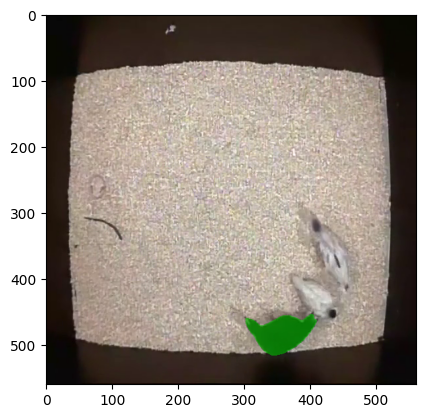

In [58]:
plt.imshow(overlay)

***

In [ ]:
from typing import Tuple, List, Optional
import numpy as np
import colorsys
import cv2
import torch

# display with matplotlib
import matplotlib.pyplot as plt


def overlay_masks_on_frame(
    frame: np.ndarray,
    masks,
    *,
    alpha: float = 0.45,
    seed: int = 0,
    object_ids: Optional[List[int]] = None,
) -> Tuple[np.ndarray, List[Tuple[int, int, int]]]:
    """
    HF-style overlay where each mask gets a unique color.
    - frame: RGB uint8 (H,W,3)
    - masks: torch.Tensor or np.ndarray, expected shape (N,H,W) or (H,W) for single mask
    - object_ids: optional list/array length N to deterministically map colors to ids
    Returns: (annotated_rgb_uint8, colors_list) where colors are (R,G,B) tuples.
    """
    # to numpy
    if isinstance(masks, torch.Tensor):
        masks_np = masks.detach().cpu().numpy()
    else:
        masks_np = np.asarray(masks)

    # normalize dims -> (N, h, w)
    if masks_np.ndim == 2:
        masks_np = masks_np[None, ...]
    if masks_np.ndim != 3:
        raise ValueError(f"Unsupported masks shape: {masks_np.shape}")
    N, mh, mw = masks_np.shape
    H, W = frame.shape[:2]
    # resize masks (nearest) if needed
    if (mh, mw) != (H, W):
        resized = []
        for i in range(N):
            m = masks_np[i]
            m_bool = (m > 0) if m.dtype != np.bool_ else m
            m_u8 = m_bool.astype(np.uint8) * 255
            m_res = cv2.resize(m_u8, (W, H), interpolation=cv2.INTER_NEAREST)
            resized.append((m_res > 0))
        masks_np = np.stack(resized, axis=0)

    # build color palette (HSV spaced)
    if object_ids is not None:
        # map unique object_ids -> distinct indices deterministically
        unique_ids, inverse = np.unique(
            np.asarray(object_ids).reshape(-1), return_inverse=True
        )
        palette_size = unique_ids.size
        id_to_color = {}
        for idx, oid in enumerate(unique_ids):
            h = ((idx + seed) / max(1, palette_size)) % 1.0
            r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.95)
            id_to_color[int(oid)] = (int(r * 255), int(g * 255), int(b * 255))
        colors = [id_to_color[int(object_ids[i])] for i in range(len(object_ids))]
    else:
        colors = []
        for i in range(N):
            h = ((i + seed) / max(1, N)) % 1.0
            r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.95)
            colors.append((int(r * 255), int(g * 255), int(b * 255)))

    # overlay (HF-style per-mask blending)
    out = frame.astype(np.float32).copy()
    for i in range(N):
        mask_bool = masks_np[i] if masks_np[i].dtype == np.bool_ else (masks_np[i] > 0)
        if not mask_bool.any():
            continue
        color = np.array(colors[i], dtype=np.float32)  # RGB
        out[mask_bool] = out[mask_bool] * (1.0 - alpha) + color * alpha

    annotated = np.clip(out, 0, 255).astype(np.uint8)
    return annotated, colors

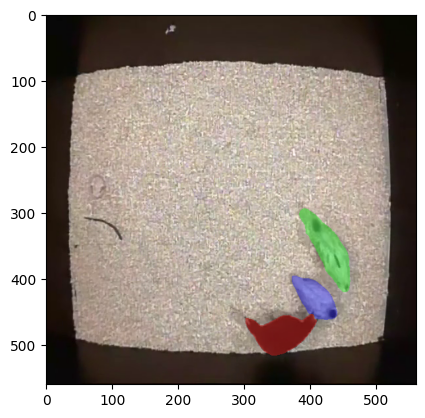

In [ ]:
frame = video_frames[FRAME_IDX]  # NHWC RGB uint8
masks = single_frame_outputs["masks"]  # torch.Size([3,560,560])
annotated, colors = overlay_masks_on_frame(frame, masks, alpha=0.45, seed=42)

plt.imshow(annotated)
# plt.axis("off")